In [8]:
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [9]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [23]:
checknumber = "00000"
path = "../Output_64_n10000/a" 
plt_path = path+"/plt"+checknumber
#path = "../Output_64_n10000/a/plt10000"
ds = AMReXDataset(plt_path)

yt : [INFO     ] 2025-03-01 13:57:27,976 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-03-01 13:57:27,977 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:57:27,978 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-01 13:57:27,978 Parameters: domain_right_edge         = [1. 1. 1.]


In [24]:
# read runlog in path by using pandas
import pandas as pd
from IPython.display import display

runlog = pd.read_csv(path+"/runlog", sep="\s+")
display(runlog)

,nstep,time,dt,<Psi_Re>,<Psi_Im>,<rho>,a
0,0,0.000000e+00,7.119940e-07,-6.439290e-15,3.552710e-15,10000,0.018316
1,1,7.119940e-07,7.119940e-07,-5.107030e-15,0.000000e+00,10000,0.018325
2,2,1.423990e-06,7.119940e-07,6.661340e-16,0.000000e+00,10000,0.018333
3,3,2.135980e-06,7.119940e-07,3.552710e-15,0.000000e+00,10000,0.018342
4,4,2.847980e-06,7.119940e-07,-6.661340e-16,0.000000e+00,10000,0.018351
...,...,...,...,...,...,...,...
9996,9996,7.117090e-03,7.119940e-07,6.394880e-14,-4.440890e-14,10000,0.075013
9997,9997,7.117810e-03,7.119940e-07,2.842170e-14,-3.108620e-14,10000,0.075017
9998,9998,7.118520e-03,7.119940e-07,3.552710e-15,-4.707350e-14,10000,0.075021
9999,9999,7.119230e-03,7.119940e-07,5.684340e-14,-3.552710e-14,10000,0.075026


In [25]:
nstep = int(checknumber)
# print row nstep+1 of runlog
print(runlog.iloc[nstep])

# print the columns of runlog to identify the correct column index
print(runlog.columns)

# print scale factor (column 7) of row nstep+1
# Replace '7' with the correct column index or column name
a = runlog.iloc[nstep]['a']  # Replace 'scale_factor' with the actual column name
print(a)

nstep       0.000000e+00
time        0.000000e+00
dt          7.119940e-07
<Psi_Re>   -6.439290e-15
<Psi_Im>    3.552710e-15
<rho>       1.000000e+04
a           1.831560e-02
Name: 0, dtype: float64
Index(['nstep', 'time', 'dt', '<Psi_Re>', '<Psi_Im>', '<rho>', 'a'], dtype='object')
0.0183156


In [46]:
def get_yt_schf_re_x_array(ds):
    Lbox_comov = ds.domain_width[0].value # comoving box length
    Lbox = Lbox_comov * a  # Physical box length
    print("Lbox = ", Lbox)
    print(ds.domain_dimensions[0])
    x = np.linspace(0, Lbox, ds.domain_dimensions[0], endpoint=False)
    xcoords =[(xi, Lbox/2, Lbox/2) for xi in x]
    SCHf_Re_x = ds.find_field_values_at_points([("boxlib", "SCHf_Re")], xcoords)
    return x, SCHf_Re_x

def analytic_plainwave_re_array(x, ds, k_mode, SCH0=100.0):
    Lbox_comov = ds.domain_width[0].value # comoving box length
    Lbox = Lbox_comov * a  # Physical box length
    k = k_mode * 2.0 * np.pi / Lbox
    hbaroverm = 0.01917152  
    omega = k * k * hbaroverm / 2.0  # Dispersion relation
    time = ds.current_time.value  # Get the current time

    # Calculate the analytical solution
    analytic_array = SCH0 * np.cos(k * x - omega * time)
    return analytic_array


In [47]:
x, numm_re = get_yt_schf_re_x_array(ds)
analy_re = analytic_plainwave_re_array(x, ds, 1)

""""L1 error """
L1_error = np.sum(np.abs(numm_re - analy_re)) / np.sum(np.abs(analy_re))
print("L1 error: ", L1_error)

Lbox =  0.0183156
64
L1 error:  1.5709946761807696 dimensionless


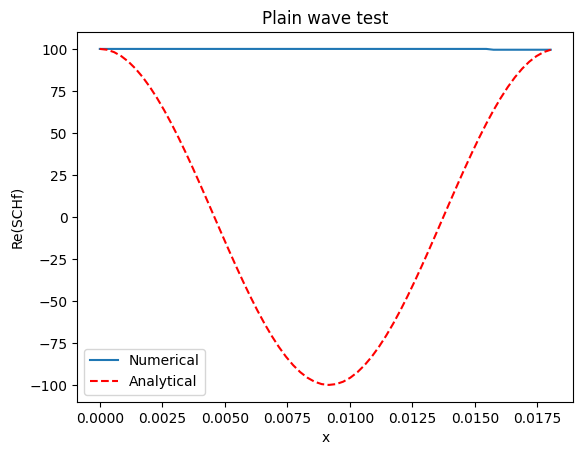

In [48]:
"""plot the numerical and analytical solution"""
fig, ax = plt.subplots()
ax.plot(x, numm_re, label='Numerical')
ax.plot(x, analy_re, label='Analytical', linestyle='--', color='red')
ax.set_title('Plain wave test')
ax.set_xlabel('x')
ax.set_ylabel('Re(SCHf)')
ax.legend()
plt.show()

In [13]:
""" find_field_values_at_point(fields, coords)
Returns the values [field1, field2,…] of the fields at the given coordinates. 
Returns a list of field values in the same order as the input fields.

find_field_values_at_points(fields, coords)
Returns the values [field1, field2,…] of the fields at the given [(x1, y1, z2), (x2, y2, z2),…] points. 
Returns a list of field values in the same order as the input fields. """


"""
64x64x64 grid leads to:
print(ds.r["boxlib", "x"])
print(ds.r["boxlib", "x"].shape)
[0.0078125 0.0078125 0.0078125 ... 0.9921875 0.9921875 0.9921875] cm
(262144,)

print(ds.r["boxlib", "SCHf_Re"])
print(ds.r["boxlib", "SCHf_Re"].shape)
[100.         100.         100.         ...  99.51847267  99.51847267
  99.51847267] dimensionless
(262144,)
"""

"""
Lets try to print the Re field in at the middle of the domain
"""
Lbox = ds.domain_width[0].value
print(ds.find_field_values_at_point([("boxlib", "SCHf_Re")], [Lbox/2, Lbox/2, Lbox/2]))
print(ds.find_field_values_at_point([("boxlib", "SCHf_Re")], [Lbox,Lbox,Lbox]))

"""
Next, lets print for multiple points
"""
#print(ds.find_field_values_at_points([("boxlib", "SCHf_Re")], [(0,0,0), (Lbox/2, Lbox/2, Lbox/2), (Lbox, Lbox, Lbox)]))

"""Lets create an array of length domain_dimensions[0] from 0 to Lbox and find the Re field at each point"""
x = np.linspace(0, Lbox, ds.domain_dimensions[0]) # doesnt work, need lets try without borders
x = np.linspace(0, Lbox, ds.domain_dimensions[0], endpoint=False)
print(x.shape)
xcoords =[(xi, Lbox/2, Lbox/2) for xi in x]
print(x)
SCHf_Re_x = ds.find_field_values_at_points([("boxlib", "SCHf_Re")], xcoords)
print(SCHf_Re_x)

[-100.] dimensionless
[] dimensionless
(64,)
[0.       0.015625 0.03125  0.046875 0.0625   0.078125 0.09375  0.109375
 0.125    0.140625 0.15625  0.171875 0.1875   0.203125 0.21875  0.234375
 0.25     0.265625 0.28125  0.296875 0.3125   0.328125 0.34375  0.359375
 0.375    0.390625 0.40625  0.421875 0.4375   0.453125 0.46875  0.484375
 0.5      0.515625 0.53125  0.546875 0.5625   0.578125 0.59375  0.609375
 0.625    0.640625 0.65625  0.671875 0.6875   0.703125 0.71875  0.734375
 0.75     0.765625 0.78125  0.796875 0.8125   0.828125 0.84375  0.859375
 0.875    0.890625 0.90625  0.921875 0.9375   0.953125 0.96875  0.984375]
[ 1.00000000e+02  9.95184727e+01  9.80785280e+01  9.56940336e+01
  9.23879533e+01  8.81921264e+01  8.31469612e+01  7.73010453e+01
  7.07106781e+01  6.34393284e+01  5.55570233e+01  4.71396737e+01
  3.82683432e+01  2.90284677e+01  1.95090322e+01  9.80171403e+00
  6.12323400e-15 -9.80171403e+00 -1.95090322e+01 -2.90284677e+01
 -3.82683432e+01 -4.71396737e+01 -5.55570233e

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc_context
from IPython.display import HTML, display  # Ensure correct import

# Assuming these functions and datasets are defined
# AMReXDatasetSeries, get_yt_schf_re_x_array, analytic_plainwave_re_array

path = "../Output_64_n10000/a/plt?????"
dsLoad = AMReXDatasetSeries(path)

# Load all datasets into a list
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2025-03-01 13:12:51,580 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-03-01 13:12:51,580 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:12:51,581 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-01 13:12:51,581 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-03-01 13:12:51,648 Parameters: current_time              = 3.55997053790648e-05
yt : [INFO     ] 2025-03-01 13:12:51,649 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:12:51,650 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-01 13:12:51,650 Parameters: domain_right_edge         = [1. 1. 1.]


yt : [INFO     ] 2025-03-01 13:12:51,719 Parameters: current_time              = 7.11994107581296e-05
yt : [INFO     ] 2025-03-01 13:12:51,720 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:12:51,720 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-01 13:12:51,721 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-03-01 13:12:51,789 Parameters: current_time              = 0.000106799116137195
yt : [INFO     ] 2025-03-01 13:12:51,789 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:12:51,790 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-01 13:12:51,790 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-03-01 13:12:51,867 Parameters: current_time              = 0.00014239882151626
yt : [INFO     ] 2025-03-01 13:12:51,868 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-03-01 13:12:51,868 Parameters

L1 error for dataset 0: 0.0 dimensionless
L1 error for dataset 1: 0.03919303407229803 dimensionless
L1 error for dataset 2: 0.07660418258285069 dimensionless
L1 error for dataset 3: 0.11232187306256942 dimensionless
L1 error for dataset 4: 0.1464322823857216 dimensionless
L1 error for dataset 5: 0.17901860206285305 dimensionless
L1 error for dataset 6: 0.2103097545237427 dimensionless
L1 error for dataset 7: 0.24046160545920178 dimensionless
L1 error for dataset 8: 0.2693869104089511 dimensionless
L1 error for dataset 9: 0.29714546577289663 dimensionless
L1 error for dataset 10: 0.32379434660590894 dimensionless
L1 error for dataset 11: 0.34938787842189195 dimensionless
L1 error for dataset 12: 0.37397765930601157 dimensionless
L1 error for dataset 13: 0.3977692562484938 dimensionless
L1 error for dataset 14: 0.4209914908273579 dimensionless
L1 error for dataset 15: 0.4433839216805653 dimensionless
L1 error for dataset 16: 0.46498394195323767 dimensionless
L1 error for dataset 17: 0.48

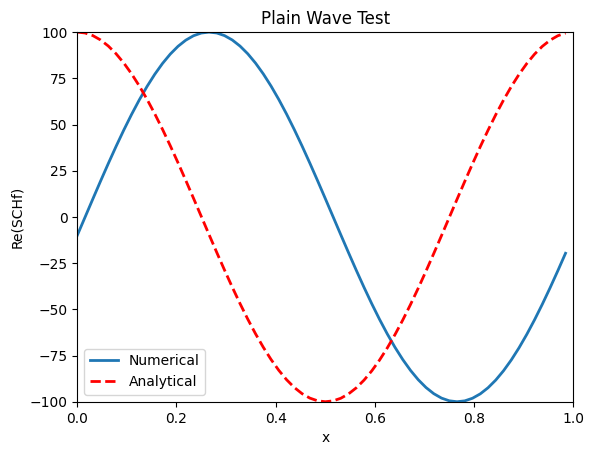

In [16]:
# Initialize figure and axis for animation
fig, ax = plt.subplots()
axis = ax  # Use the created axis from `plt.subplots`, no need for a separate `axis`
ax.set_xlim(0, 1)
ax.set_ylim(-100, 100)

# Create line objects with labels for legend
line_num, = ax.plot([], [], lw=2, label='Numerical')  # Ensure label is correctly assigned
line_ana, = ax.plot([], [], lw=2, linestyle='--', color='red', label='Analytical')
ax.set_title('Plain Wave Test')
ax.set_xlabel('x')
ax.set_ylabel('Re(SCHf)')
ax.legend()  # This will now work since labels are set

# Function to update the animation for each frame
def animate(i):
    # Get numerical and analytical solutions for dataset `ds[i]`
    x, numm_re = get_yt_schf_re_x_array(ds[i])
    analy_re = analytic_plainwave_re_array(x, ds[i], 1)
    
    # Update the line data
    line_num.set_data(x, numm_re)
    line_ana.set_data(x, analy_re)
    
    return line_num, line_ana

# Create animation
animation = FuncAnimation(fig, animate, frames=len(ds), interval=200, blit=True)

# Display animation as HTML5 video
with rc_context({"mathtext.fontset": "stix"}):
    video = animation.to_html5_video()
    display(HTML(video))  # Correct usage of `HTML` and `display`

# Calculate and print L1 error for all datasets
for i, dataset in enumerate(ds):
    x, numm_re = get_yt_schf_re_x_array(dataset)
    analy_re = analytic_plainwave_re_array(x, dataset, 1)
    L1_error = np.sum(np.abs(numm_re - analy_re)) / np.sum(np.abs(analy_re))
    print(f"L1 error for dataset {i}: {L1_error}")

In [8]:
path = "../Output_64_n10000/plt?????"
dsLoad = AMReXDatasetSeries(path)

In [9]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2024-12-16 15:16:18,406 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-16 15:16:18,406 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-16 15:16:18,407 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 15:16:18,407 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2024-12-16 15:16:18,545 Parameters: current_time              = 0.106121226086055
yt : [INFO     ] 2024-12-16 15:16:18,545 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-16 15:16:18,546 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 15:16:18,546 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2024-12-16 15:16:18,675 Parameters: current_time              = 0.212242452172111
yt : [INFO     ] 2024-12-16 15:16:18,676 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-16 15:16:18,677 Parameters: domain_left_edge    

In [10]:
x, numm_re = get_yt_schf_re_x_array(ds[2])
analy_re = analytic_plainwave_re_array(x, ds[2], 1)

""""L1 error """
L1_error = np.sum(np.abs(numm_re - analy_re)) / np.sum(np.abs(analy_re))
print("L1 error: ", L1_error)

L1 error:  6.449083436237582e-05 dimensionless


In [11]:
"""lets plot schf_re analytically and numerrically over x and animate it. One graph for one ds"""


'lets plot schf_re analytically and numerrically over x and animate it. One graph for one ds'

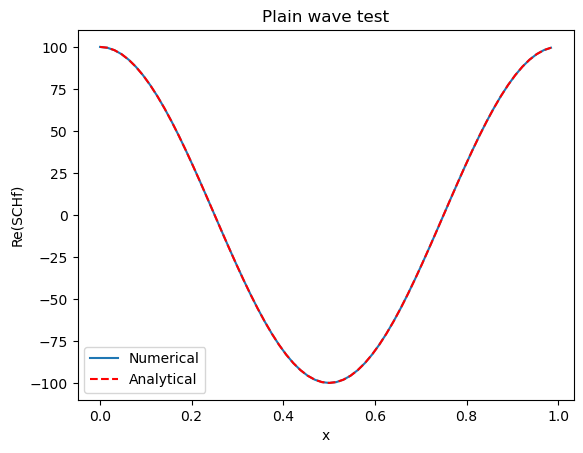

AttributeError: module 'matplotlib.pyplot' has no attribute '_switch_ds'

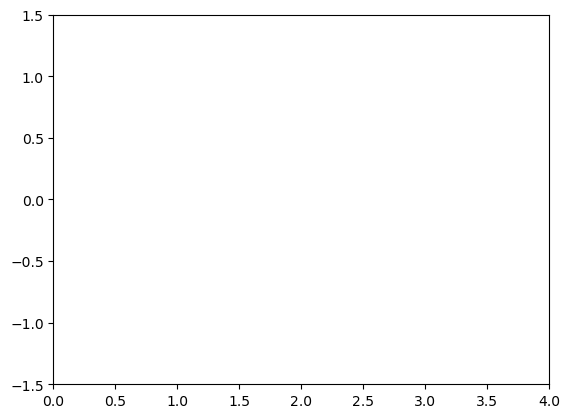

In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc_context
from IPython.display import HTML

x, numm_re = get_yt_schf_re_x_array(ds[0])
analy_re = analytic_plainwave_re_array(x, ds[0], 1)

"""plot the numerical and analytical solution"""
fig, ax = plt.subplots()
ax.plot(x, numm_re, label='Numerical')
ax.plot(x, analy_re, label='Analytical', linestyle='--', color='red')
ax.set_title('Plain wave test')
ax.set_xlabel('x')
ax.set_ylabel('Re(SCHf)')
ax.legend()
plt.show()


# Animation setup
axis = plt.axes(xlim=(0, 4), ylim=(-1.5, 1.5))
line, = axis.plot([], [], lw=3)
p
def animate(i):
    # Recreate the plot for each frame
    plt._switch_ds(dsLoad[i])
    line.set_data(plt.x, plt.y)
    line.set_color("green")
    return line,

animation = FuncAnimation(fig, animate, frames=len(dsLoad))

# Display animation
with rc_context({"mathtext.fontset": "stix"}):
    video = animation.to_html5_video()
    display(HTML(video))